## Imports

In [1]:
import math
import random
import os

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from mtcnn import MTCNN
import pickle

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [5]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.models import resnet18


## Functions

In [6]:
def load_raw_image(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [7]:
def detect_face(img):
    results = detector.detect_faces(img)
    if len(results) == 0:
        return None
    return results[0]  

In [8]:
def get_rotation_angle(left_eye, right_eye):
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = math.degrees(math.atan2(dy, dx))
    return angle

In [9]:
def rotate_image(img, center, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated

In [10]:
def crop_face(img, box, margin=0.2):
    x, y, w, h = box
    img_h, img_w = img.shape[:2]

    mx = int(w * margin)
    my = int(h * margin)

    x1 = max(0, x - mx)
    y1 = max(0, y - my)
    x2 = min(img_w, x + w + mx)
    y2 = min(img_h, y + h + my)

    return img[y1:y2, x1:x2]

In [11]:
def preprocess_face(face):
    face = cv2.resize(face, (112, 112))
    return face

In [12]:
def extract_embedding(face_img):
    face_tensor = inference_transform(face_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        embedding = model(face_tensor)
    
    embedding = F.normalize(embedding, p=2, dim=1)
    
    return embedding.squeeze(0)

In [13]:
def detect_align_crop(image_path):

    # 1️⃣ Load image
    img = load_raw_image(image_path)
    if img is None:
        return None

    # 2️⃣ Detect face
    detection = detect_face(img)
    if detection is None:
        return None

    # 3️⃣ Extract box + keypoints
    box = detection['box']
    keypoints = detection['keypoints']

    left_eye = keypoints['left_eye']
    right_eye = keypoints['right_eye']

    # 4️⃣ Compute rotation angle
    angle = get_rotation_angle(left_eye, right_eye)

    # 5️⃣ Compute eye center
    eye_center = (
        int((left_eye[0] + right_eye[0]) / 2),
        int((left_eye[1] + right_eye[1]) / 2)
    )

    # 6️⃣ Rotate full image
    rotated_img = rotate_image(img, eye_center, angle)

    # 7️⃣ Crop face using rotated image
    face = crop_face(rotated_img, box, margin=0.35)
    if face is None or face.size == 0:
        return None

    # 8️⃣ Final preprocessing (112x112)
    face = preprocess_face(face)

    return face

In [14]:
def build_database(processed_dir):

    database = {}

    for person_name in sorted(os.listdir(processed_dir)):

        person_path = os.path.join(processed_dir, person_name)

        if not os.path.isdir(person_path):
            continue

        embeddings = []

        for img_name in os.listdir(person_path):

            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(person_path, img_name)

            # Load already processed image
            face = load_raw_image(img_path)
            if face is None:
                continue

            # Extract embedding
            emb = extract_embedding(face)
            embeddings.append(emb)

        if len(embeddings) > 0:

            # Mean embedding per identity
            mean_embedding = torch.mean(torch.stack(embeddings), dim=0)

            # Normalize again (important)
            mean_embedding = F.normalize(mean_embedding, dim=0)

            database[person_name] = mean_embedding

    return database

In [15]:
def recognize_face(image_path, threshold=0.5):

    # 1️⃣ Detect + align + crop
    face = detect_align_crop(image_path)

    if face is None:
        return "No Face Detected", 0.0

    # 2️⃣ Extract embedding
    new_embedding = extract_embedding(face)

    # 3️⃣ Compare with DB
    database = torch.load("database/face_database.pth", map_location=device)

    best_score = -1
    best_match = "Unknown"

    for name, db_embedding in database.items():

        score = F.cosine_similarity(
            new_embedding.unsqueeze(0),
            db_embedding.unsqueeze(0)
        ).item()

        if score > best_score:
            best_score = score
            best_match = name

    # 4️⃣ Apply threshold
    if best_score >= threshold:
        return best_match, best_score
    else:
        return "Unknown", best_score

In [16]:
def cosine_similarity(emb1, emb2):
    return F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

In [17]:
def cosine_sim(a, b):
    if not torch.is_tensor(a):
        a = torch.tensor(a)

    if not torch.is_tensor(b):
        b = torch.tensor(b)

    return F.cosine_similarity(a, b, dim=0).item()

## Raw Images to Input ready (Already done)

In [18]:
detector = MTCNN()

In [19]:
raw_data_dir = "data/Original Images"
save_root = "data/processed_faces"

os.makedirs(save_root, exist_ok=True)

image_count = 0
skipped = 0

for person in sorted(os.listdir(raw_data_dir)):
    person_dir = os.path.join(raw_data_dir, person)

    if not os.path.isdir(person_dir):
        continue

    save_person_dir = os.path.join(save_root, person)
    os.makedirs(save_person_dir, exist_ok=True)

    for img_name in os.listdir(person_dir):

        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        image_path = os.path.join(person_dir, img_name)

        img = load_raw_image(image_path)
        if img is None:
            skipped += 1
            continue

        detections = detector.detect_faces(img)
        if len(detections) == 0:
            skipped += 1
            continue

        detection = detections[0]  
        box = detection['box']
        keypoints = detection['keypoints']

        left_eye = keypoints['left_eye']
        right_eye = keypoints['right_eye']

        angle = get_rotation_angle(left_eye, right_eye)

        eye_center = (
            int((left_eye[0] + right_eye[0]) / 2),
            int((left_eye[1] + right_eye[1]) / 2)
        )

        rotated_img = rotate_image(img, eye_center, angle)

        face = crop_face(rotated_img, box, margin=0.35)
        if face is None:
            skipped += 1
            continue

        face = preprocess_face(face)

        save_path = os.path.join(save_person_dir, img_name)
        cv2.imwrite(save_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))

        image_count += 1

In [20]:
print(f"Total processed faces: {image_count}")
print(f"Skipped images: {skipped}")

Total processed faces: 2496
Skipped images: 4


## Creating Labels

In [19]:
DATASET_DIR = "data/processed_faces"

samples = []

label_map = {}
current_label = 0

In [20]:
for person in sorted(os.listdir(DATASET_DIR)):
    person_dir = os.path.join(DATASET_DIR, person)
    if not os.path.isdir(person_dir):
        continue

    label_map[person] = current_label

    for img_name in os.listdir(person_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(person_dir, img_name)
            samples.append((img_path, current_label))

    current_label += 1

In [21]:
print(f"Total samples: {len(samples)}")
print(f"Total classes: {len(label_map)}")

Total samples: 2496
Total classes: 29


In [22]:
print("Class mapping:", label_map)

Class mapping: {'Akshay Kumar': 0, 'Alexandra Daddario': 1, 'Alia Bhatt': 2, 'Amitabh Bachchan': 3, 'Andy Samberg': 4, 'Anushka Sharma': 5, 'Billie Eilish': 6, 'Brad Pitt': 7, 'Camila Cabello': 8, 'Charlize Theron': 9, 'Claire Holt': 10, 'Courtney Cox': 11, 'Dwayne Johnson': 12, 'Elizabeth Olsen': 13, 'Ellen Degeneres': 14, 'Henry Cavill': 15, 'Hrithik Roshan': 16, 'Hugh Jackman': 17, 'Jessica Alba': 18, 'Lisa Kudrow': 19, 'Margot Robbie': 20, 'Natalie Portman': 21, 'Priyanka Chopra': 22, 'Robert Downey Jr': 23, 'Roger Federer': 24, 'Tom Cruise': 25, 'Vijay Deverakonda': 26, 'Virat Kohli': 27, 'Zac Efron': 28}


## Training & Validation Data Split

In [23]:
train_samples, val_samples = train_test_split(
    samples,
    test_size=0.1,
    stratify=[s[1] for s in samples],
    random_state=42
)

In [24]:
print(f"Train: {len(train_samples)}")
print(f"Val:   {len(val_samples)}")

Train: 2246
Val:   250


## Dataset & Dataloader

In [25]:
class FaceDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img.transpose(2,0,1), dtype=torch.float32)

        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [26]:
BATCH_SIZE = 32
NUM_WORKERS = 0

In [27]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [28]:
train_dataset = FaceDataset(train_samples, transform=train_transform)
val_dataset = FaceDataset(val_samples, transform=val_transform)

In [29]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [30]:
images, labels = next(iter(train_loader))

In [31]:
print(images.shape)   
print(labels.shape)   
print(images.min(), images.max())

torch.Size([32, 3, 112, 112])
torch.Size([32])
tensor(-1.) tensor(1.)


## Face Images to 512-D Vector Embeddings

In [32]:
class FaceEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        
        backbone = resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.embedding = nn.Linear(512, embedding_dim)

    def forward(self, x):
        x = self.backbone(x)          
        x = x.view(x.size(0), -1)     
        
        x = self.embedding(x)         
        x = F.normalize(x, p=2, dim=1)
        
        return x

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [34]:
model = FaceEmbeddingModel().to(device)
model.eval()

C:\Users\Ahmad Tanveer\OneDrive\Desktop\Face_Recognition\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Ahmad Tanveer\OneDrive\Desktop\Face_Recognition\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FaceEmbeddingModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [35]:
images = images.to(device)

In [36]:
with torch.no_grad():
    embeddings = model(images)

print("Input shape:", images.shape)
print("Embedding shape:", embeddings.shape)

Input shape: torch.Size([32, 3, 112, 112])
Embedding shape: torch.Size([32, 512])


In [37]:
norms = torch.norm(embeddings, dim=1)
print("Norm min:", norms.min().item())
print("Norm max:", norms.max().item())

Norm min: 0.9999999403953552
Norm max: 1.0000001192092896


## Training

In [38]:
class ArcFaceLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes, s=64.0, m=0.5):
        super().__init__()
        self.s = s
        self.m = m
        self.num_classes = num_classes
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Normalize embeddings and class weights
        embeddings = F.normalize(embeddings, dim=1)
        weight = F.normalize(self.weight, dim=1)

        # Cosine similarity
        cosine = torch.matmul(embeddings, weight.t())
        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.m)

        # One-hot encode labels
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        # Replace only correct class
        output = cosine * (1 - one_hot) + target_logits * one_hot

        # Scale
        output *= self.s
        return output

In [39]:
num_classes = len(label_map)  
arcface = ArcFaceLoss(embedding_dim=512, num_classes=num_classes, s=32.0, m=0.3).to(device)
criterion = nn.CrossEntropyLoss()

In [40]:
model = model.to(device)
model.train()

FaceEmbeddingModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [41]:
patience = 5
best_val_loss = float('inf')
counter = 0

In [42]:
BATCH_SIZE = 32
EPOCHS = 20
optimizer = torch.optim.Adam([
    {"params": model.backbone.parameters(), "lr": 1e-5},
    {"params": model.embedding.parameters(), "lr": 1e-4},
    {"params": arcface.parameters(), "lr": 1e-4}
])

In [43]:
for epoch in range(EPOCHS):
    running_loss = 0.0
    model.train()
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        
        embeddings = model(images)          
        logits = arcface(embeddings, labels)  
        loss = criterion(logits, labels)    
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    avg_train_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Average Loss: {avg_train_loss:.4f}")

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            embeddings = model(images)
            logits = arcface(embeddings, labels)
            loss = criterion(logits, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Validation Loss: {avg_val_loss:.4f}")

    # ===== EARLY STOPPING LOGIC =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "model/face_model.pth")
        print("✅ Validation improved, model saved.")
    else:
        counter += 1
        print(f"⚠️ No improvement. Early stopping counter: {counter}/{patience}")

        if counter >= patience:
            print("🛑 Early stopping triggered.")
            break

    print("-"*50)

Epoch [1/20], Step [10/71], Loss: 12.7813
Epoch [1/20], Step [20/71], Loss: 13.2022
Epoch [1/20], Step [30/71], Loss: 12.4905
Epoch [1/20], Step [40/71], Loss: 12.0914
Epoch [1/20], Step [50/71], Loss: 11.9960
Epoch [1/20], Step [60/71], Loss: 11.8503
Epoch [1/20], Step [70/71], Loss: 11.9222
Epoch [1/20] Average Loss: 12.3457
Validation Loss: 11.3660
✅ Validation improved, model saved.
--------------------------------------------------
Epoch [2/20], Step [10/71], Loss: 11.0382
Epoch [2/20], Step [20/71], Loss: 11.0980
Epoch [2/20], Step [30/71], Loss: 10.3941
Epoch [2/20], Step [40/71], Loss: 10.4579
Epoch [2/20], Step [50/71], Loss: 10.7560
Epoch [2/20], Step [60/71], Loss: 9.9272
Epoch [2/20], Step [70/71], Loss: 10.5653
Epoch [2/20] Average Loss: 10.4714
Validation Loss: 9.8621
✅ Validation improved, model saved.
--------------------------------------------------
Epoch [3/20], Step [10/71], Loss: 9.2582
Epoch [3/20], Step [20/71], Loss: 9.0163
Epoch [3/20], Step [30/71], Loss: 8.82

In [44]:
model = FaceEmbeddingModel(embedding_dim=512)
model.load_state_dict(torch.load("model/face_model.pth", map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [45]:
inference_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [46]:
database = build_database(DATASET_DIR)
torch.save(database, "database/face_database.pth")

print("Database created with", len(database), "identities.")

Database created with 29 identities.


In [47]:
name, score = recognize_face("images.jpeg", threshold=0.55)

print("Prediction:", name)
print("Similarity:", score)

Prediction: Anushka Sharma
Similarity: 0.6393990516662598


## Loading Database

In [48]:
database = torch.load("database/face_database.pth", map_location="cpu")

In [49]:
print(type(database))
print(len(database))

<class 'dict'>
29


In [50]:
print(type(labels[0]))
print(labels[0])

<class 'torch.Tensor'>
tensor(18, device='cuda:0')


In [51]:
# unique_labels = list(set(labels))
# label_to_id = {name: i for i, name in enumerate(unique_labels)}

label_ids = [l.item() for l in labels]

In [52]:
embeddings = []
labels = []

for person, emb_data in database.items():

    if isinstance(emb_data, list):
        for emb in emb_data:
            embeddings.append(emb)
            labels.append(person)

    else:
        embeddings.append(emb_data)
        labels.append(person)

import numpy as np
embeddings = np.array(embeddings)

In [53]:
print("Embeddings shape:", embeddings.shape)
print("Labels length:", len(labels))

Embeddings shape: (29, 512)
Labels length: 29


## Visualization

In [54]:
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embeddings)

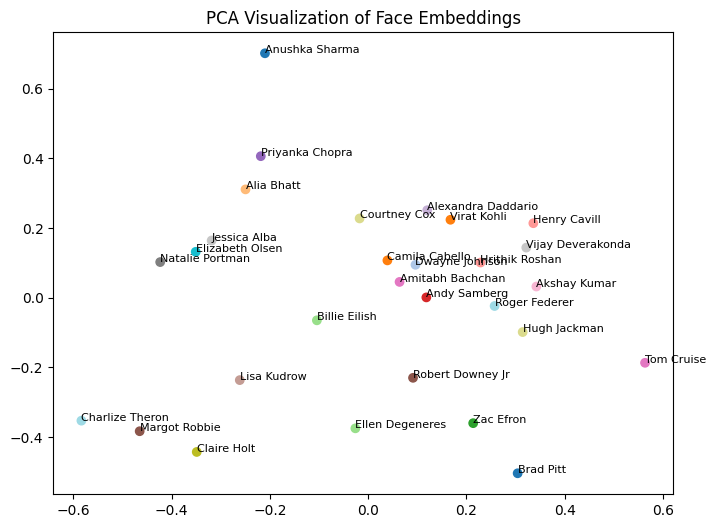

In [55]:
# Convert embeddings to numpy
embeddings = np.array(embeddings)

# Create numeric labels
unique_labels = list(set(labels))
label_to_id = {name:i for i,name in enumerate(unique_labels)}
label_ids = [label_to_id[l] for l in labels]

# PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    c=label_ids,
    cmap="tab20"
)

# Add names on points
for i, name in enumerate(labels):
    plt.text(
        reduced_embeddings[i,0],
        reduced_embeddings[i,1],
        name,
        fontsize=8
    )

plt.title("PCA Visualization of Face Embeddings")

plt.show()

## Testing Cosine Similarity

In [56]:
print(cosine_sim(database["Alia Bhatt"], database["Anushka Sharma"]))
print(cosine_sim(database["Alia Bhatt"], database["Alia Bhatt"]))

0.18967843055725098
1.000000238418579


In [57]:
name, score = recognize_face("images.jpeg")

print(name, score)

Anushka Sharma 0.6393990516662598


In [58]:
model.eval()
model.cpu()
example_input = torch.randn(1, 3, 112, 112)

traced_model = torch.jit.trace(model, example_input)

torch.jit.save(traced_model, "model/face_model_scripted.pt")